# RankNet on LETOR4
### Learning to Rank — Pairwise Neural Approach
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: ScoringMLP (MLP) trained with RankNet pairwise BCE
**Loss**: RankNet BCE  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **RankNet**, a foundational pairwise Learning-to-Rank algorithm.
The underlying network is the same `ScoringMLP` as in the Pointwise notebook — the only
difference is the training signal: instead of MSE on individual labels, we use a
**pairwise Binary Cross-Entropy loss** that directly optimises the relative ordering of documents.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | Model definition using `ltr.models.ScoringMLP` |
| 5    | Pairwise loss intuition (RankNet BCE) |
| 6    | Single-fold training with early stopping on Val NDCG@10 |
| 7    | 5-Fold Evaluation (Standard LETOR Folds) |
| 8    | Ablation study across 4 architectures |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/LTR", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

In [2]:
# ── Extract MQ2008 dataset ────────────────────────────────────────────────────
# Upload MQ2008.zip to /content/ before running this cell.
import zipfile, os

ZIP_PATH  = "/content/MQ2008.zip"
DATA_PATH = "/content/MQ2008"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data     import load_fold
from ltr.models   import ScoringMLP
from ltr.train    import train, train_multiseed, set_seed
from ltr.metrics  import mean_ndcg, per_query_ndcg, paired_significance
from ltr.evaluate import cross_fold_eval

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content/MQ2008"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
PyTorch : 2.11.0+cu128


## Step 4 · Data Loading

In [4]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print(f"Batch: {len(sample_qids)} queries")
print(f"Query 0 features shape: {sample_feats[0].shape}")
print(f"Query 0 labels        : {sample_labels[0].tolist()}")


  Fold 1: 471 train | 157 val | 156 test queries
Batch: 4 queries
Query 0 features shape: torch.Size([8, 46])
Query 0 labels        : [1.0, 1.0, 2.0, 0.0, 1.0, 2.0, 2.0, 2.0]


## Step 5 · Model Definition

In [5]:
model = ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2).to(DEVICE)
print(model)

with torch.no_grad():
    sample_scores = model(sample_feats[0].to(DEVICE))
print(f"\nForward pass: {sample_feats[0].shape} → {sample_scores.shape}")


ScoringMLP(
  (scorer): Sequential(
    (0): Linear(in_features=46, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Forward pass: torch.Size([8, 46]) → torch.Size([8, 1])


## Step 6 · The Pairwise Loss (RankNet BCE)

To calculate the probability that document $i$ is better than document $j$, we pass
their score difference through a sigmoid function:

$$P_{ij} = \sigma(s_i - s_j)$$

The loss is then the negative log of that probability:

$$L = -\log \sigma(s_i - s_j)$$

This is equivalent to `binary_cross_entropy_with_logits(s_i - s_j, target=1)` for all
valid pairs where `label_i > label_j`.


## Step 7 · Training (Single Fold, Baseline Run)

Early stopping is based on **validation NDCG@10** (Fix #2).

In [6]:
import matplotlib.pyplot as plt

def plot_training_curve(val_ndcg_history, model_name, k=10):
    """Plot validation NDCG@k over epochs."""
    epochs = range(1, len(val_ndcg_history) + 1)
    best_epoch = val_ndcg_history.index(max(val_ndcg_history)) + 1

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, val_ndcg_history, marker="o", color="royalblue",
             label=f"Val NDCG@{k}")
    plt.axvline(best_epoch, color="purple", linestyle=":", linewidth=2,
                label=f"Best epoch ({best_epoch})")
    plt.title(f"{model_name} — Validation NDCG@{k}", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel(f"NDCG@{k}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [7]:
set_seed(42)
model = ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2).to(DEVICE)

trained_model, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="ranknet",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Val NDCG@10: 0.5327  ← best
Epoch 02/50 | Val NDCG@10: 0.5381  ← best
Epoch 03/50 | Val NDCG@10: 0.5339
Epoch 04/50 | Val NDCG@10: 0.5339
Epoch 05/50 | Val NDCG@10: 0.5427  ← best
Epoch 06/50 | Val NDCG@10: 0.5369
Epoch 07/50 | Val NDCG@10: 0.5448  ← best
Epoch 08/50 | Val NDCG@10: 0.5462  ← best
Epoch 09/50 | Val NDCG@10: 0.5339
Epoch 10/50 | Val NDCG@10: 0.5479  ← best
Epoch 11/50 | Val NDCG@10: 0.5516  ← best
Epoch 12/50 | Val NDCG@10: 0.5374
Epoch 13/50 | Val NDCG@10: 0.5600  ← best
Epoch 14/50 | Val NDCG@10: 0.5482
Epoch 15/50 | Val NDCG@10: 0.5444
Epoch 16/50 | Val NDCG@10: 0.5313
Epoch 17/50 | Val NDCG@10: 0.5445
Epoch 18/50 | Val NDCG@10: 0.5423
Epoch 19/50 | Val NDCG@10: 0.5534
Epoch 20/50 | Val NDCG@10: 0.5401
Epoch 21/50 | Val NDCG@10: 0.5487
Epoch 22/50 | Val NDCG@10: 0.5453
Epoch 23/50 | Val NDCG@10: 0.5448
Early stopping at epoch 23 (no improvement for 10 consecutive epochs).


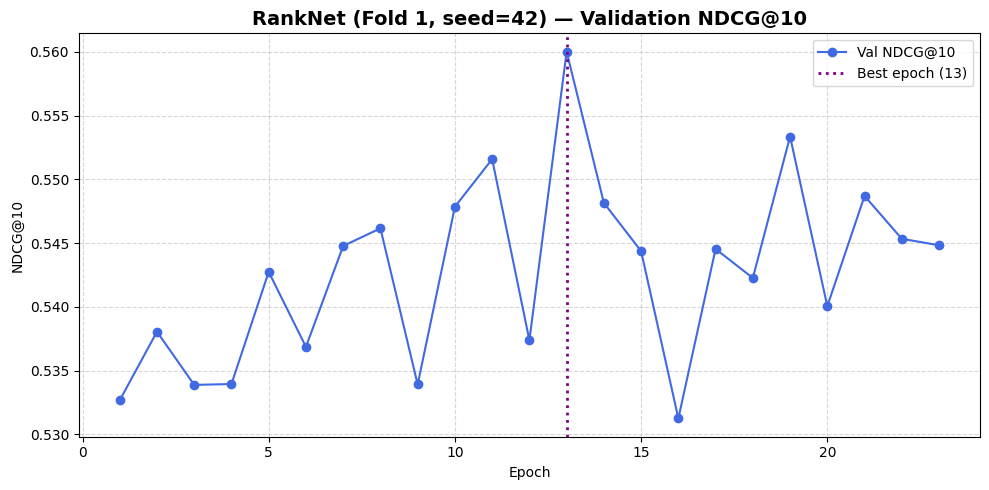

In [8]:
plot_training_curve(val_ndcg_history, "RankNet (Fold 1, seed=42)", k=10)


## Step 8 · Single-Fold Test Set Evaluation

In [9]:
test_ndcg = mean_ndcg(trained_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3504
  NDCG@3  : 0.3816
  NDCG@5  : 0.4330
  NDCG@10 : 0.4762


## Results — Single-Fold (Fold 1, seed=42)

These results are not enough since the model may perform differently for different data, so we use the 5-fold results below for a fair assessment.

## Step 9 · 5-Fold Evaluation (Standard LETOR Folds)

We are using the exact 5 test splits provided by the dataset authors, rather than
shuffling and making our own cross-validation splits. This makes sure our results
can be fairly compared to published papers.

Each fold is trained across **3 random seeds** and results are reported as **Mean ± Std** (Fix #8).


In [10]:
def print_results_table(results, title, k_list=(1, 3, 5, 10)):
    """Pretty-print a cross_fold_eval or train_multiseed results dict."""
    summary = results.get("overall", results.get("summary", {}))
    print(f"\n{'═'*45}")
    print(f"  {title}")
    print(f"{'═'*45}")
    print(f"{'Metric':<10}  {'Mean':>8}  {'Std':>8}")
    print(f"{'─'*45}")
    for k in k_list:
        if k in summary:
            m, s = summary[k]["mean"], summary[k]["std"]
            print(f"NDCG@{k:<5}  {m:>8.4f}  {s:>8.4f}")
    print(f"{'═'*45}")


In [11]:
ranknet_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=46, hidden_dims=[64, 32], dropout=0.2),
    mode="ranknet",
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)

print_results_table(ranknet_results, "RANKNET — 5-Fold Results")



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════


  Fold 1: 471 train | 157 val | 156 test queries
  NDCG@1  : 0.3397 ± 0.0109
  NDCG@3  : 0.3845 ± 0.0030
  NDCG@5  : 0.4293 ± 0.0027
  NDCG@10 : 0.4720 ± 0.0031

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════


  Fold 2: 471 train | 156 val | 157 test queries
  NDCG@1  : 0.3376 ± 0.0135
  NDCG@3  : 0.3662 ± 0.0031
  NDCG@5  : 0.4131 ± 0.0035
  NDCG@10 : 0.4506 ± 0.0007

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════


  Fold 3: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.3510 ± 0.0111
  NDCG@3  : 0.3770 ± 0.0045
  NDCG@5  : 0.4254 ± 0.0029
  NDCG@10 : 0.4789 ± 0.0021

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════


  Fold 4: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.4133 ± 0.0044
  NDCG@3  : 0.4634 ± 0.0044
  NDCG@5  : 0.5035 ± 0.0055
  NDCG@10 : 0.5508 ± 0.0051

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════


  Fold 5: 470 train | 157 val | 157 test queries
  NDCG@1  : 0.4034 ± 0.0069
  NDCG@3  : 0.4507 ± 0.0052
  NDCG@5  : 0.4916 ± 0.0053
  NDCG@10 : 0.5442 ± 0.0037

═══════════════════════════════════════════════════════
  OVERALL RESULTS (RANKNET)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3690 ± 0.0341
  NDCG@3  : 0.4084 ± 0.0406
  NDCG@5  : 0.4526 ± 0.0375
  NDCG@10 : 0.4993 ± 0.0406
═══════════════════════════════════════════════════════


═════════════════════════════════════════════
  RANKNET — 5-Fold Results
═════════════════════════════════════════════
Metric          Mean       Std
─────────────────────────────────────────────
NDCG@1        0.3690    0.0341
NDCG@3        0.4084    0.0406
NDCG@5        0.4526    0.0375
NDCG@10       0.4993    0.0406
═════════════════════════════════════════════


## Results — 5-Fold Cross-Validation

The table above reports the mean and standard deviation of NDCG@K across all 5 standard LETOR folds and 3 random seeds (15 runs total).
- **higher mean** - It is said that pairwise loss directly optimizes the Ranking order instead of regressing over the relevance labels and it proven by the results.
- However, **The difference is minimal** - This might be due to the ***less size of Dataset***
- More priority for the top documents becuase the **NDCG difference is higher at NDCG@1**

## Step 10 · Save Results

In [12]:
import json

os.makedirs("/content/ltr_results", exist_ok=True)

def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

with open("/content/ltr_results/ranknet_results.json", "w") as f:
    json.dump(to_serialisable(ranknet_results), f, indent=2)

print("Results saved to /content/ltr_results/ranknet_results.json")


Results saved to /content/ltr_results/ranknet_results.json


## Ablation Study — Architecture Comparison

We lock the data to **Fold 1** and swap out the underlying network architecture,
keeping everything else identical. This isolates the impact of depth and
dropout regularization on NDCG@10.

| Config | Hidden dims | Dropout |
|---|---|---|
| Linear | `[]` | 0.0 |
| Baseline | `[64, 32]` | 0.0 |
| Regularized | `[64, 32]` | 0.2 |
| Deep | `[128, 64, 32, 16]` | 0.2 |


In [13]:
# ── Lock data to Fold 1 ───────────────────────────────────────────────────────
train_loader_f1, val_loader_f1, test_loader_f1 = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

# ── Ablation configurations ───────────────────────────────────────────────────
ablation_configs = {
    "Linear":      {"hidden_dims": [],              "dropout": 0.0},
    "Baseline":    {"hidden_dims": [64, 32],         "dropout": 0.0},
    "Regularized": {"hidden_dims": [64, 32],         "dropout": 0.2},
    "Deep":        {"hidden_dims": [128, 64, 32, 16],"dropout": 0.2},
}

ablation_results = {}

for arch_name, cfg in ablation_configs.items():
    print(f"\nTraining {arch_name} ...")
    result = train_multiseed(
        model_fn=lambda h=cfg["hidden_dims"], d=cfg["dropout"]: ScoringMLP(46, h, d),
        train_loader=train_loader_f1,
        val_loader=val_loader_f1,
        test_loader=test_loader_f1,
        mode="ranknet",
        seeds=SEEDS,
        k_list=K_LIST,
        device=DEVICE,
        epochs=50,
        patience=10,
        verbose=False,
    )
    ablation_results[arch_name] = result["summary"]
    ndcg10 = result["summary"][10]
    print(f"  NDCG@10: {ndcg10['mean']:.4f} ± {ndcg10['std']:.4f}")


  Fold 1: 471 train | 157 val | 156 test queries

Training Linear ...
  NDCG@10: 0.4771 ± 0.0018

Training Baseline ...
  NDCG@10: 0.4740 ± 0.0085

Training Regularized ...
  NDCG@10: 0.4720 ± 0.0031

Training Deep ...
  NDCG@10: 0.4697 ± 0.0074


In [14]:
# ── Ablation results table ────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)")
print(f"{'═'*65}")
print(f"{'Architecture':<15}  {'NDCG@1':>10}  {'NDCG@3':>10}  {'NDCG@5':>10}  {'NDCG@10':>10}")
print(f"{'─'*65}")
for arch_name, summary in ablation_results.items():
    row = "  ".join(
        f"{summary[k]['mean']:>6.4f}±{summary[k]['std']:.4f}" for k in [1, 3, 5, 10]
    )
    print(f"{arch_name:<15}  {row}")
print(f"{'═'*65}")



═════════════════════════════════════════════════════════════════
  ABLATION STUDY — NDCG@10 (Fold 1, Mean ± Std over 3 seeds)
═════════════════════════════════════════════════════════════════
Architecture         NDCG@1      NDCG@3      NDCG@5     NDCG@10
─────────────────────────────────────────────────────────────────
Linear           0.3390±0.0086  0.3876±0.0028  0.4372±0.0018  0.4771±0.0018
Baseline         0.3397±0.0182  0.3883±0.0034  0.4339±0.0087  0.4740±0.0085
Regularized      0.3397±0.0109  0.3845±0.0030  0.4293±0.0027  0.4720±0.0031
Deep             0.3369±0.0082  0.3816±0.0078  0.4208±0.0123  0.4697±0.0074
═════════════════════════════════════════════════════════════════


## Results — Ablation Study

- Because the pairwise loss is already a stronger learning signal than MSE, even shallow architectures tend to achieve competitive NDCG.
- Dropout regularization remains useful to prevent overfitting on small folds.

## Conclusion

RankNet directly optimises the relative ordering of document pairs, which aligns
more closely with the NDCG metric than MSE on absolute labels.
